# AE Reconstruction Sanity Check

Loads the trained AE checkpoint (`checkpoint-9.pth`), runs Splatt3r on a DROID-100 sample,
encodes/decodes through the AE, and compares original vs reconstructed point clouds.

Expects: final MSE ~0.0014 (matching training loss at epoch 9).

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import einops
from pytorch3d.ops import sample_farthest_points as fps

GWM_PATH = os.environ.get('GWM_PATH', os.path.expanduser('~/Workspace/gaussianwm'))
sys.path.insert(0, GWM_PATH)
sys.path.insert(0, os.path.join(GWM_PATH, 'gaussianwm'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
# Load one batch from DROID-100
from omegaconf import OmegaConf
from processor.datasets import build_gaussian_splatting_reconstruction_dataset

dataset_cfg = OmegaConf.create({
    'dataset_name': 'droid',
    'data_path': os.path.join(GWM_PATH, 'data') + '/',
    'segment_length': 10,
    'context_length': 2,
    'action_dim': 10,
    'image_size': 128,
    'augment': False,
    'val_ratio': 0.1,
    'seed': 0,
    'camera_keys': ['primary', 'secondary'],
    'action_keys': ['actions'],
    'future_action_window_size': 15,
    'subsample_length': 100,
    'shuffle_buffer_size': 1000,
    'traj_transform_threads': 48,
    'traj_read_threads': 48,
})

ds_train = build_gaussian_splatting_reconstruction_dataset('train', cfg=dataset_cfg)
obs, action, reward = next(iter(ds_train))
print(f'obs shape: {obs.shape}, dtype: {obs.dtype}')  # [T, H, W, C]

2026-02-10 12:58:16.492500: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-10 12:58:16.492549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-10 12:58:16.522550: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-10 12:58:16.590797: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-10 12:58:17.389735: W tensorflow/compiler/tf2

Loading existing dataset statistics from /home/frankcholula/Workspace/gaussianwm/data/droid_100/1.0.0/dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json.


2026-02-10 12:58:21.352597: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization



######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################

Threads per Dataset: %s [48]
Reads per Dataset: %s [48]
Constructing datasets...


2026-02-10 12:58:21.947274: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


Applying frame transforms on dataset...


/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/datasets.py:252: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  left_frames = torch.from_numpy(left_frames)


obs shape: torch.Size([10, 128, 128, 3]), dtype: torch.uint8


In [3]:
# Run Splatt3r on first frame -> 14D point cloud
from processor.regressor import Splatt3rRegressor
import util.tensor_utils as TensorUtils

splatt3r = Splatt3rRegressor().to(device)
splatt3r.eval()

# Replicate training preprocessing exactly (train_vae.py lines 52-64)
image = obs.unsqueeze(0).float()  # [1, T, H, W, C]
image = einops.rearrange(image, 'b t h w c -> (b t) c h w').to(device)

with torch.no_grad():
    points_raw, _ = splatt3r.forward_tensor(image)

# Color normalization (train_vae.py lines 60-62)
SH_C0 = 0.28209479177387814
colors = 0.5 + SH_C0 * points_raw[..., -4:-1]
points_raw[..., -4:-1] = colors / 255.0

# FPS downsample to 2048 (train_vae.py line 64)
POINT_CLOUD_SIZE = 2048
points_all, _ = fps(points_raw, K=POINT_CLOUD_SIZE)

# Take first frame for visualization
points = points_all[:1]  # [1, 2048, 14]
print(f'Point cloud shape: {points.shape}')
print(f'Range per dim: min={points.min(dim=1).values.squeeze()}, max={points.max(dim=1).values.squeeze()}')

/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/regressor.py:164: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializa

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
Point cloud shape: torch.Size([1, 2048, 14])
Range per dim: min=tensor([-1.5370e-01, -1.4688e-01,  1.6890e+00,  1.0459e-03,  1.0013e-03,
         9.9471e-04,  2.5250e-01,  2.0580e-01, -7.7999e-01,  1.0501e-01,
        -3.8403e-05, -3.2564e-05, -3.3936e-05,  8.7294e-01], device='cuda:0'), max=tensor([ 0.0856,  0.1023,  2.2631,  0.0106,  0.0047,  0.0040,  0.6296,  0.5645,
        -0.5126,  0.6021,  1.0001,  1.0000,  1.0000,  1.0000], device='cuda:0')


In [4]:
# Load trained AE (matching configs/vae/transformer.yaml + train_vae_single_gpu.yaml)
from gaussianwm.encoder.models_ae import create_autoencoder

model = create_autoencoder(
    depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
).to(device)

ckpt_path = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', 'checkpoint-9.pth')
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model'])
model.eval()
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loaded checkpoint from epoch 9
Parameters: 812,686


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [5]:
# AE reconstruction: encode -> decode (same as train_vae.py line 71)
with torch.no_grad():
    outputs = model(points, points)
    recon = outputs['logits']  # [1, 2048, 14]

mse = torch.nn.functional.mse_loss(recon, points).item()
print(f'Overall MSE: {mse:.6f}  (training final: ~0.0014)')

# Per-dimension MSE breakdown
dim_labels = ['x', 'y', 'z', 'scale_0', 'scale_1', 'scale_2',
              'rot_0', 'rot_1', 'rot_2', 'rot_3',
              'sh_r', 'sh_g', 'sh_b', 'opacity']
per_dim_mse = ((recon - points) ** 2).mean(dim=(0, 1))  # [14]
print('\nPer-dimension MSE:')
for i, (label, val) in enumerate(zip(dim_labels, per_dim_mse)):
    print(f'  {label:>8s}: {val.item():.6f}')

Overall MSE: 0.000725  (training final: ~0.0014)

Per-dimension MSE:
         x: 0.000258
         y: 0.000213
         z: 0.001373
   scale_0: 0.000018
   scale_1: 0.000013
   scale_2: 0.000017
     rot_0: 0.001543
     rot_1: 0.000622
     rot_2: 0.000748
     rot_3: 0.001115
      sh_r: 0.001854
      sh_g: 0.000595
      sh_b: 0.001668
   opacity: 0.000108


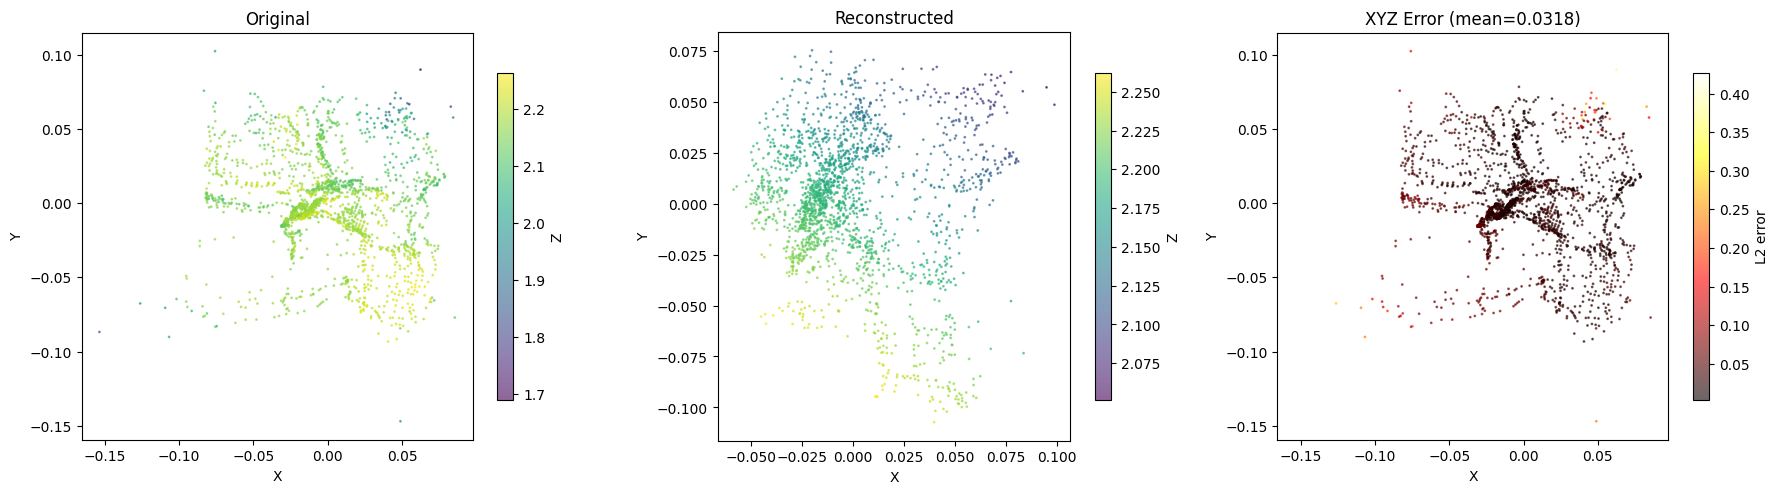

In [6]:
# Visualize: original vs reconstructed XYZ
orig = points[0].cpu().numpy()      # [2048, 14]
rec = recon[0].cpu().numpy()         # [2048, 14]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top-down view (X vs Y, colored by Z)
for ax, data, title in [(axes[0], orig, 'Original'), (axes[1], rec, 'Reconstructed')]:
    sc = ax.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='viridis', s=1, alpha=0.6)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Z')

# Error magnitude per point
error = np.sqrt(((orig[:, :3] - rec[:, :3]) ** 2).sum(axis=1))
sc = axes[2].scatter(orig[:, 0], orig[:, 1], c=error, cmap='hot', s=1, alpha=0.6)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].set_title(f'XYZ Error (mean={error.mean():.4f})')
axes[2].set_aspect('equal')
plt.colorbar(sc, ax=axes[2], shrink=0.8, label='L2 error')

plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_reconstruction_xyz.png'), dpi=150)
plt.show()

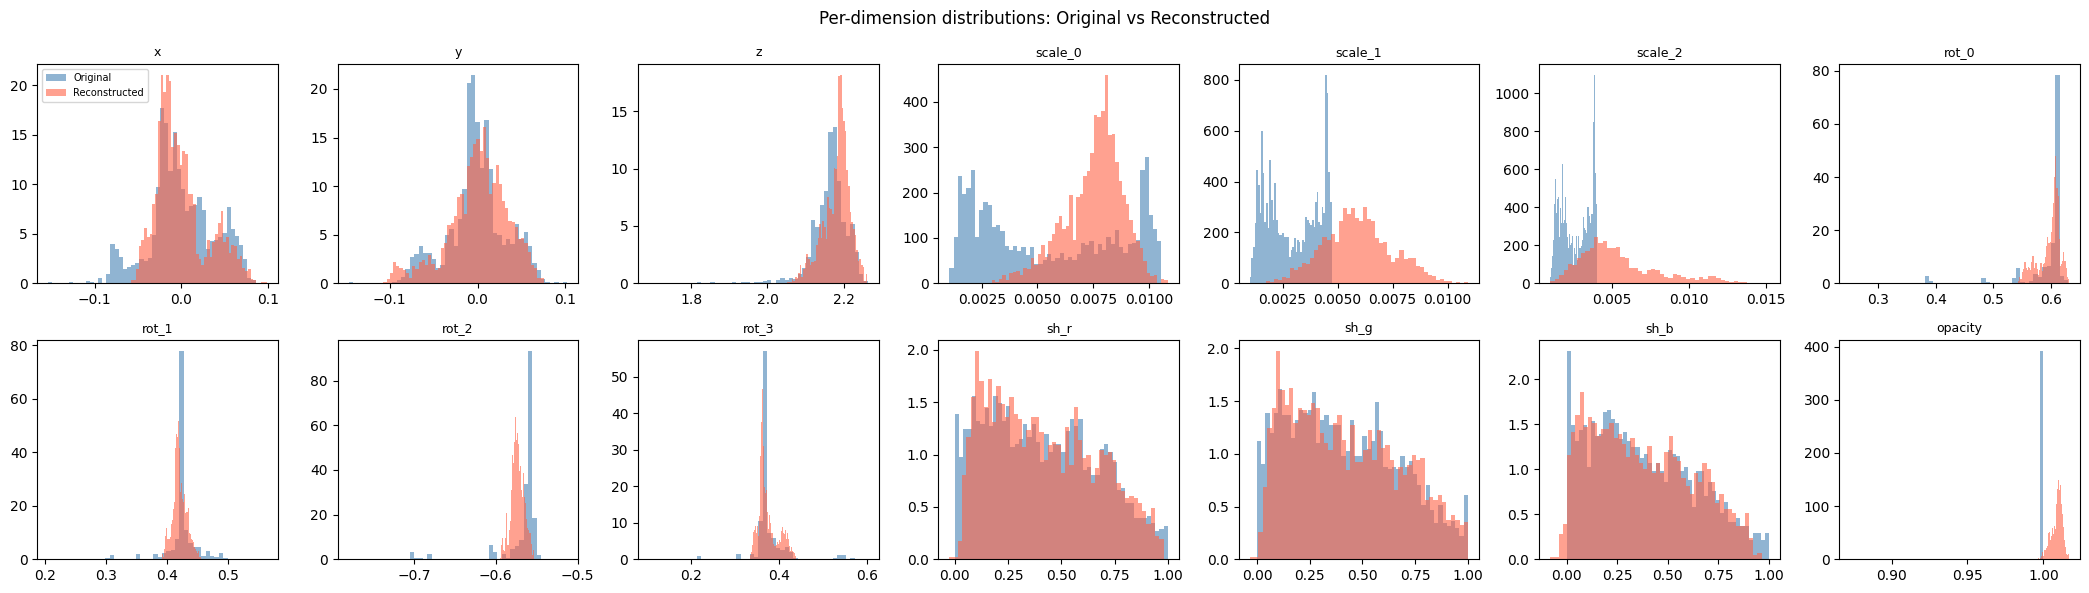

In [7]:
# Per-dimension histograms: original (blue) vs reconstructed (red)
fig, axes = plt.subplots(2, 7, figsize=(21, 6))
axes = axes.flatten()

for d in range(14):
    ax = axes[d]
    ax.hist(orig[:, d], bins=50, alpha=0.6, color='steelblue', label='Original', density=True)
    ax.hist(rec[:, d], bins=50, alpha=0.6, color='tomato', label='Reconstructed', density=True)
    ax.set_title(dim_labels[d], fontsize=9)
    if d == 0:
        ax.legend(fontsize=7)

plt.suptitle('Per-dimension distributions: Original vs Reconstructed', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_reconstruction_histograms.png'), dpi=150)
plt.show()

## Checkpoint-10 Comparison

Comparing epoch 9 vs epoch 10 reconstruction to check if continued training improves quality at these low loss values.

In [8]:
# Load checkpoint-10 and compare reconstruction
model_10 = create_autoencoder(
    depth=4, dim=64, M=64, latent_dim=64, output_dim=14, N=2048, deterministic=True
).to(device)

ckpt10_path = os.path.join(GWM_PATH, 'logs', 'vae_single_gpu', 'checkpoint-10.pth')
ckpt10 = torch.load(ckpt10_path, map_location=device, weights_only=False)
model_10.load_state_dict(ckpt10['model'])
model_10.eval()
print(f'Loaded checkpoint from epoch {ckpt10["epoch"]}')

with torch.no_grad():
    recon_10 = model_10(points, points)['logits']

mse_10 = torch.nn.functional.mse_loss(recon_10, points).item()
per_dim_mse_10 = ((recon_10 - points) ** 2).mean(dim=(0, 1))

# Side-by-side comparison
print(f'{"Dimension":>10s}  {"ckpt-9":>10s}  {"ckpt-10":>10s}  {"delta":>10s}')
print('-' * 46)
for i, label in enumerate(dim_labels):
    v9 = per_dim_mse[i].item()
    v10 = per_dim_mse_10[i].item()
    delta = v10 - v9
    arrow = 'v' if delta < 0 else '^'
    print(f'{label:>10s}  {v9:10.6f}  {v10:10.6f}  {delta:+10.6f} {arrow}')
print('-' * 46)
print(f'{"Overall":>10s}  {mse:10.6f}  {mse_10:10.6f}  {mse_10 - mse:+10.6f} {"v" if mse_10 < mse else "^"}')

Loaded checkpoint from epoch 10
 Dimension      ckpt-9     ckpt-10       delta
----------------------------------------------
         x    0.000258    0.000245   -0.000013 v
         y    0.000213    0.000245   +0.000032 ^
         z    0.001373    0.001154   -0.000219 v
   scale_0    0.000018    0.000014   -0.000003 v
   scale_1    0.000013    0.000005   -0.000008 v
   scale_2    0.000017    0.000014   -0.000003 v
     rot_0    0.001543    0.001421   -0.000122 v
     rot_1    0.000622    0.000589   -0.000033 v
     rot_2    0.000748    0.000734   -0.000014 v
     rot_3    0.001115    0.001033   -0.000082 v
      sh_r    0.001854    0.001648   -0.000207 v
      sh_g    0.000595    0.000473   -0.000122 v
      sh_b    0.001668    0.001747   +0.000079 ^
   opacity    0.000108    0.000079   -0.000029 v
----------------------------------------------
   Overall    0.000725    0.000672   -0.000053 v


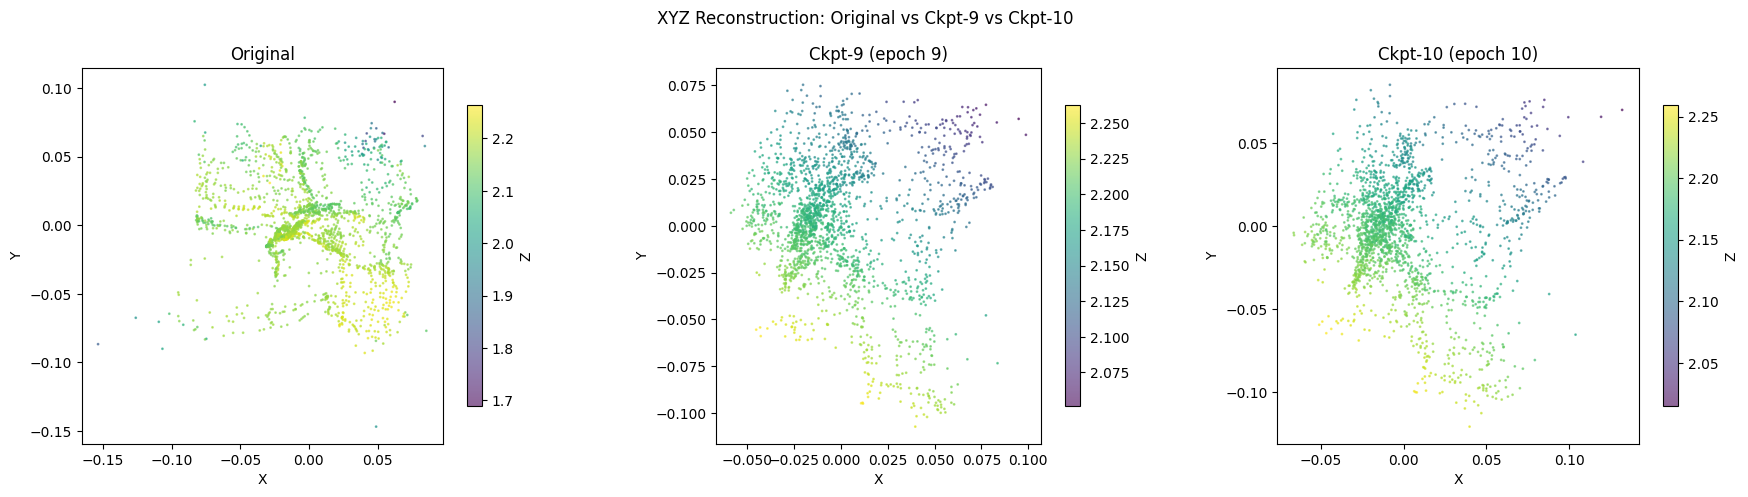

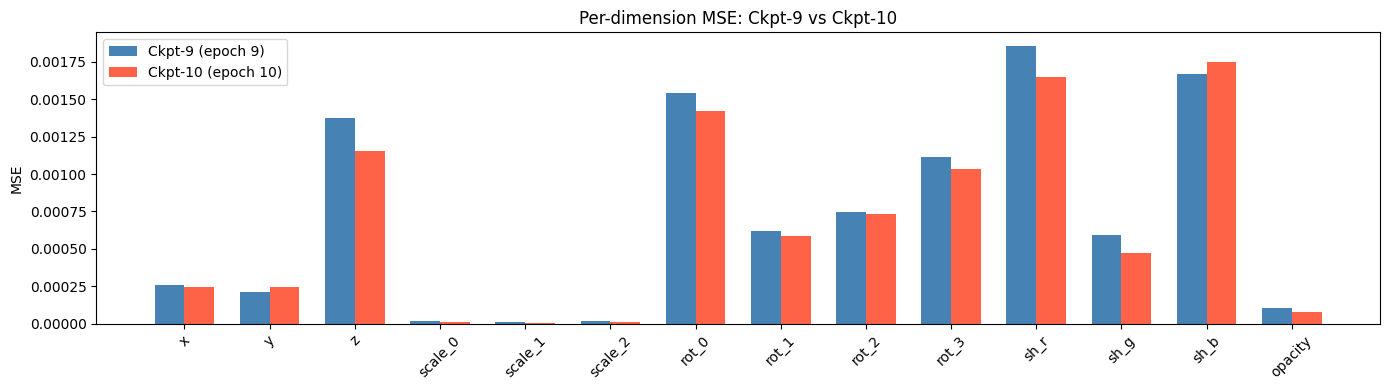

In [9]:
# Visual comparison: original vs ckpt-9 vs ckpt-10
rec_10 = recon_10[0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title in [(axes[0], orig, 'Original'),
                         (axes[1], rec, 'Ckpt-9 (epoch 9)'),
                         (axes[2], rec_10, 'Ckpt-10 (epoch 10)')]:
    sc = ax.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='viridis', s=1, alpha=0.6)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.set_title(title); ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Z')
plt.suptitle('XYZ Reconstruction: Original vs Ckpt-9 vs Ckpt-10')
plt.tight_layout()

# Per-dimension MSE bar chart
fig2, ax2 = plt.subplots(figsize=(14, 4))
x = np.arange(14)
w = 0.35
ax2.bar(x - w/2, per_dim_mse.cpu().numpy(), w, label='Ckpt-9 (epoch 9)', color='steelblue')
ax2.bar(x + w/2, per_dim_mse_10.cpu().numpy(), w, label='Ckpt-10 (epoch 10)', color='tomato')
ax2.set_xticks(x); ax2.set_xticklabels(dim_labels, rotation=45)
ax2.set_ylabel('MSE'); ax2.set_title('Per-dimension MSE: Ckpt-9 vs Ckpt-10')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(GWM_PATH, 'notebooks', 'ae_reconstruction_ckpt_comparison.png'), dpi=150)
plt.show()